# Week 4 - PyTorch Training Structure and Hyperparameters

This notebook turns the neural-network ideas from the previous weeks into the standard PyTorch workflow used in many computer vision projects. The goal is not just to make a model run; the goal is to see where each responsibility belongs.

A typical PyTorch training notebook has these parts:

1. Select a computation device, such as GPU or CPU.
2. Build a `Dataset` that returns one example at a time.
3. Build `DataLoader`s that batch, shuffle, and parallelize data loading.
4. Define an `nn.Module` model.
5. Choose the loss function, optimizer, scheduler, and other hyperparameters.
6. Run a training loop with a separate validation phase.
7. Save the best model checkpoint.

The code below keeps those pieces separate so it is easier to debug and easier to modify later.


In [1]:
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import v2 as transforms
from PIL import Image
from pathlib import Path

# Reproducibility: this makes many random choices repeatable.
# Some GPU operations can still be nondeterministic, but this is a good default.
torch.manual_seed(0)

# Device selection controls where tensors and model parameters live.
# CUDA is NVIDIA GPU support. MPS is Apple Silicon GPU support.
if torch.cuda.is_available():
    device = torch.device("cuda")
elif getattr(torch.backends, "mps", None) and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")


Using device: cuda


## Dataset

A PyTorch `Dataset` represents the raw examples. Its job is to answer two questions:

- How many examples are available?
- For a particular index, what image and label should be returned?

The dataset should not train the model, update weights, or create batches. It should only load one example at a time. This version expects the common image-classification folder layout:

```text
data/train/class_0/example.jpg
data/train/class_1/example.jpg
data/val/class_0/example.jpg
data/val/class_1/example.jpg
```

Each subfolder name becomes a class name. The class names are converted into integer labels because `CrossEntropyLoss` expects class labels such as `0`, `1`, `2`, and so on.


In [2]:
class ImageClassificationDataset(Dataset):
    """Image classification dataset using one folder per class."""

    def __init__(self, root_directory, image_transform=None, class_to_index=None):
        self.root_directory = Path(root_directory)
        self.image_transform = image_transform

        # Accept the most common image file extensions.
        self.image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

        # Infer class names from subdirectories, unless a mapping was provided.
        # Passing the training mapping into validation keeps labels consistent.
        if class_to_index is None:
            class_names = sorted(
                path.name
                for path in self.root_directory.iterdir()
                if path.is_dir()
            )
            self.class_to_index = {
                class_name: class_index
                for class_index, class_name in enumerate(class_names)
            }
        else:
            self.class_to_index = dict(class_to_index)

        self.samples = []

        # Store pairs of (image_path, integer_label).
        # __getitem__ will use these pairs later to load one example at a time.
        for class_name, class_index in self.class_to_index.items():
            class_directory = self.root_directory / class_name
            if not class_directory.exists():
                continue

            for image_path in sorted(class_directory.rglob("*")):
                if image_path.suffix.lower() in self.image_extensions:
                    self.samples.append((image_path, class_index))

        if len(self.samples) == 0:
            raise ValueError(
                f"No images found in {self.root_directory}. "
                "Expected folders like root/class_name/image.jpg."
            )

    def __len__(self):
        # PyTorch calls this to know how many examples are in the dataset.
        return len(self.samples)

    def __getitem__(self, sample_index):
        # PyTorch calls this to retrieve one example.
        image_path, class_label = self.samples[sample_index]

        # Convert every image to RGB so all examples have 3 channels.
        image = Image.open(image_path).convert("RGB")

        # Transforms handle resizing, augmentation, tensor conversion, and normalization.
        if self.image_transform is not None:
            image = self.image_transform(image)

        return image, class_label


## Transforms

Transforms define what happens to an image before it reaches the model. Training transforms often include randomness because random crops, flips, and color changes act as data augmentation. Augmentation makes the model see slightly different versions of the training images, which can reduce overfitting.

Validation transforms should usually be deterministic. We want validation accuracy to measure the model, not the luck of a random crop.

The normalization constants below are ImageNet defaults. They are especially useful when using ImageNet-pretrained models, but they are also reasonable defaults for many RGB image experiments.


In [3]:
training_transforms = transforms.Compose([
    # RandomResizedCrop changes both image scale and viewpoint.
    # This is a hyperparameter: size and scale control how aggressive the crop is.
    transforms.RandomResizedCrop(
        size=224,
        scale=(0.7, 1.0),
    ),

    # Only use flipping when it does not change the meaning of the label.
    transforms.RandomHorizontalFlip(p=0.5),

    # Color jitter helps the model rely less on exact lighting or saturation.
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.05,
    ),

    # Convert PIL images to PyTorch image tensors.
    transforms.ToImage(),

    # Convert integer pixel values to floating point values in [0, 1].
    transforms.ToDtype(dtype=torch.float32, scale=True),

    # Normalize each color channel.
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

validation_transforms = transforms.Compose([
    # Validation preprocessing is fixed so metrics are comparable across epochs.
    transforms.Resize(size=256),
    transforms.CenterCrop(size=224),
    transforms.ToImage(),
    transforms.ToDtype(dtype=torch.float32, scale=True),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])


## Datasets and DataLoaders

After defining the dataset class and transforms, we create separate datasets for training and validation. The training dataset uses random augmentation; the validation dataset uses fixed preprocessing.

A `DataLoader` wraps a dataset and handles batching. Important DataLoader hyperparameters include:

- `batch_size`: number of examples per gradient update.
- `shuffle`: usually `True` for training and `False` for validation.
- `num_workers`: number of CPU worker processes used to load data.
- `pin_memory`: can speed up CPU-to-GPU transfer when using CUDA.

Update the paths below to match the dataset location on your machine.

```Note:``` This assumes the `imagenette2` dataset has been placed in a folder parallel to the repo root called `datasets`. You can download it from [fast.ai's imagenette2 repo](https://github.com/fastai/imagenette). (This code uses the "Full size" version)

In [4]:
training_dataset = ImageClassificationDataset(
    root_directory="../../datasets/imagenette2/train",
    image_transform=training_transforms,
)

validation_dataset = ImageClassificationDataset(
    root_directory="../../datasets/imagenette2/val",
    image_transform=validation_transforms,
    class_to_index=training_dataset.class_to_index,
)

# The number of classes is inferred from the training folders.
number_of_classes = len(training_dataset.class_to_index)
print(f"Number of classes: {number_of_classes}")
print(f"Training examples: {len(training_dataset)}")
print(f"Validation examples: {len(validation_dataset)}")

# pin_memory is useful for CUDA, but not needed for CPU or Apple MPS.
pin_memory = device.type == "cuda"

training_dataloader = DataLoader(
    dataset=training_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=4,
    pin_memory=pin_memory,
)

validation_dataloader = DataLoader(
    dataset=validation_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=4,
    pin_memory=pin_memory,
)


Number of classes: 10
Training examples: 9469
Validation examples: 3925


## Model

The model below is a multilayer perceptron (MLP). It is intentionally simple: it flattens each image into one long vector and then applies fully connected layers.

This is not the strongest architecture for image classification because flattening discards spatial structure. Convolutional neural networks and vision transformers usually work better for images. However, an MLP is a useful teaching model because the flow is easy to see:

```text
image tensor -> flattened vector -> hidden layers -> class logits
```

The final layer outputs logits, not probabilities. Logits are raw class scores. We pass logits directly into `CrossEntropyLoss`; we do not apply softmax first.


In [5]:
class ImageClassificationMultilayerPerceptron(nn.Module):
    def __init__(self, number_of_classes):
        super().__init__()

        image_channels = 3
        image_height = 224
        image_width = 224
        number_of_input_features = image_channels * image_height * image_width

        self.network = nn.Sequential(
            # [batch_size, 3, 224, 224] -> [batch_size, 150528]
            nn.Flatten(),

            nn.Linear(
                in_features=number_of_input_features,
                out_features=512,
            ),
            nn.ReLU(),

            # Dropout randomly turns off hidden activations during training.
            # This is a regularization hyperparameter.
            nn.Dropout(p=0.2),

            nn.Linear(
                in_features=512,
                out_features=256,
            ),
            nn.ReLU(),
            nn.Dropout(p=0.2),

            # One output logit per class.
            nn.Linear(
                in_features=256,
                out_features=number_of_classes,
            ),
        )

    def forward(self, input_images):
        return self.network(input_images)


classification_model = ImageClassificationMultilayerPerceptron(
    number_of_classes=number_of_classes,
).to(device)

print(classification_model)


ImageClassificationMultilayerPerceptron(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=150528, out_features=512, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.2, inplace=False)
    (7): Linear(in_features=256, out_features=10, bias=True)
  )
)


## Loss Function, Optimizer, and Scheduler

These choices are hyperparameters because they shape how learning happens.

`CrossEntropyLoss` is the standard loss for multiclass classification. It expects logits with shape `[batch_size, number_of_classes]` and integer labels with shape `[batch_size]`. Label smoothing makes the target labels slightly less extreme, which can improve generalization.

`AdamW` is a strong default optimizer. It combines adaptive learning rates with decoupled weight decay. The learning rate controls step size, while weight decay discourages very large weights.

The scheduler changes the learning rate over time. Cosine annealing gradually lowers the learning rate during training, allowing larger updates early and smaller refinements later.


In [6]:
loss_function = nn.CrossEntropyLoss(
    label_smoothing=0.05,
)

optimizer = torch.optim.AdamW(
    params=classification_model.parameters(),
    lr=3e-4,
    weight_decay=1e-4,
)

number_of_epochs = 50

learning_rate_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer=optimizer,
    T_max=number_of_epochs,
)

# Keep a history dictionary so we can plot learning curves later.
history = {
    "training_loss": [],
    "validation_loss": [],
    "validation_accuracy": [],
}


## Training and Validation Loop

Each epoch has two phases.

During training, the model uses random augmentation, computes gradients, and updates weights. During validation, the model uses deterministic preprocessing, does not compute gradients, and does not update weights.

The most important PyTorch loop commands are:

- `model.train()` turns on training behavior such as dropout.
- `optimizer.zero_grad()` clears old gradients.
- `loss.backward()` computes new gradients using backpropagation.
- `optimizer.step()` updates the weights.
- `model.eval()` turns off training-only behavior.
- `torch.no_grad()` avoids storing gradient information during validation.

The loop also saves the model whenever validation accuracy improves. This is called best-checkpoint saving.


In [7]:
best_validation_accuracy = 0.0

for epoch_index in range(number_of_epochs):
    # --------------------------------------------------------
    # Training phase
    # --------------------------------------------------------
    classification_model.train()
    total_training_loss = 0.0

    for training_images, training_labels in training_dataloader:
        # Move the batch to the same device as the model.
        training_images = training_images.to(device, non_blocking=True)
        training_labels = training_labels.to(device, non_blocking=True)

        # Forward pass: compute predicted logits.
        predicted_training_logits = classification_model(training_images)

        # Compare predictions with the true labels.
        training_loss = loss_function(
            predicted_training_logits,
            training_labels,
        )

        # Backpropagation follows the standard PyTorch order:
        # clear old gradients -> compute new gradients -> update parameters.
        optimizer.zero_grad(set_to_none=True)
        training_loss.backward()

        # Gradient clipping prevents extremely large gradients from causing
        # unstable parameter updates.
        torch.nn.utils.clip_grad_norm_(
            parameters=classification_model.parameters(),
            max_norm=1.0,
        )

        optimizer.step()

        # Multiply by batch size so the epoch average is weighted correctly.
        total_training_loss += training_loss.item() * training_images.size(0)

    learning_rate_scheduler.step()
    average_training_loss = total_training_loss / len(training_dataset)

    # --------------------------------------------------------
    # Validation phase
    # --------------------------------------------------------
    classification_model.eval()
    total_validation_loss = 0.0
    number_of_correct_validation_predictions = 0
    number_of_validation_examples = 0

    with torch.no_grad():
        for validation_images, validation_labels in validation_dataloader:
            validation_images = validation_images.to(device, non_blocking=True)
            validation_labels = validation_labels.to(device, non_blocking=True)

            predicted_validation_logits = classification_model(validation_images)

            validation_loss = loss_function(
                predicted_validation_logits,
                validation_labels,
            )

            total_validation_loss += validation_loss.item() * validation_images.size(0)

            predicted_validation_classes = predicted_validation_logits.argmax(dim=1)
            number_of_correct_validation_predictions += (
                predicted_validation_classes == validation_labels
            ).sum().item()
            number_of_validation_examples += validation_labels.size(0)

    average_validation_loss = total_validation_loss / len(validation_dataset)
    validation_accuracy = (
        number_of_correct_validation_predictions
        / number_of_validation_examples
    )

    history["training_loss"].append(average_training_loss)
    history["validation_loss"].append(average_validation_loss)
    history["validation_accuracy"].append(validation_accuracy)

    # Save the model whenever validation accuracy improves.
    if validation_accuracy > best_validation_accuracy:
        best_validation_accuracy = validation_accuracy
        torch.save(
            classification_model.state_dict(),
            "best_multilayer_perceptron.pt",
        )

    current_learning_rate = learning_rate_scheduler.get_last_lr()[0]
    print(
        f"Epoch {epoch_index + 1:03d} | "
        f"Training Loss: {average_training_loss:.4f} | "
        f"Validation Loss: {average_validation_loss:.4f} | "
        f"Validation Accuracy: {validation_accuracy:.4f} | "
        f"LR: {current_learning_rate:.6f}"
    )

print(f"Best Validation Accuracy: {best_validation_accuracy:.4f}")


Epoch 001 | Training Loss: 3.8168 | Validation Loss: 2.2703 | Validation Accuracy: 0.1896 | LR: 0.000300
Epoch 002 | Training Loss: 2.2605 | Validation Loss: 2.1698 | Validation Accuracy: 0.2257 | LR: 0.000299
Epoch 003 | Training Loss: 2.1626 | Validation Loss: 2.0659 | Validation Accuracy: 0.2966 | LR: 0.000297
Epoch 004 | Training Loss: 2.0785 | Validation Loss: 2.0351 | Validation Accuracy: 0.3065 | LR: 0.000295
Epoch 005 | Training Loss: 2.0551 | Validation Loss: 2.0079 | Validation Accuracy: 0.3259 | LR: 0.000293
Epoch 006 | Training Loss: 2.0183 | Validation Loss: 1.9767 | Validation Accuracy: 0.3409 | LR: 0.000289
Epoch 007 | Training Loss: 2.0031 | Validation Loss: 1.9545 | Validation Accuracy: 0.3529 | LR: 0.000286
Epoch 008 | Training Loss: 1.9791 | Validation Loss: 1.9377 | Validation Accuracy: 0.3656 | LR: 0.000281
Epoch 009 | Training Loss: 1.9519 | Validation Loss: 1.8981 | Validation Accuracy: 0.3732 | LR: 0.000277
Epoch 010 | Training Loss: 1.9546 | Validation Loss: 1.

## Validation Classification Report and Confusion Matrix

Accuracy gives one overall number, but it does not show which classes the model is confusing. A classification report breaks performance down by class using precision, recall, and F1-score.

A confusion matrix gives a visual summary of mistakes. Rows are the true labels, and columns are the predicted labels. A strong classifier should have most of its counts on the diagonal.


Validation Classification Report
                  precision    recall  f1-score   support

           tench       0.59      0.67      0.63       387
English springer       0.44      0.54      0.48       395
 cassette player       0.52      0.49      0.51       357
       chain saw       0.36      0.20      0.26       386
          church       0.54      0.47      0.50       409
     French horn       0.34      0.51      0.41       394
   garbage truck       0.52      0.56      0.54       389
        gas pump       0.40      0.32      0.36       419
       golf ball       0.49      0.45      0.47       399
       parachute       0.62      0.63      0.63       390

        accuracy                           0.48      3925
       macro avg       0.48      0.48      0.48      3925
    weighted avg       0.48      0.48      0.48      3925



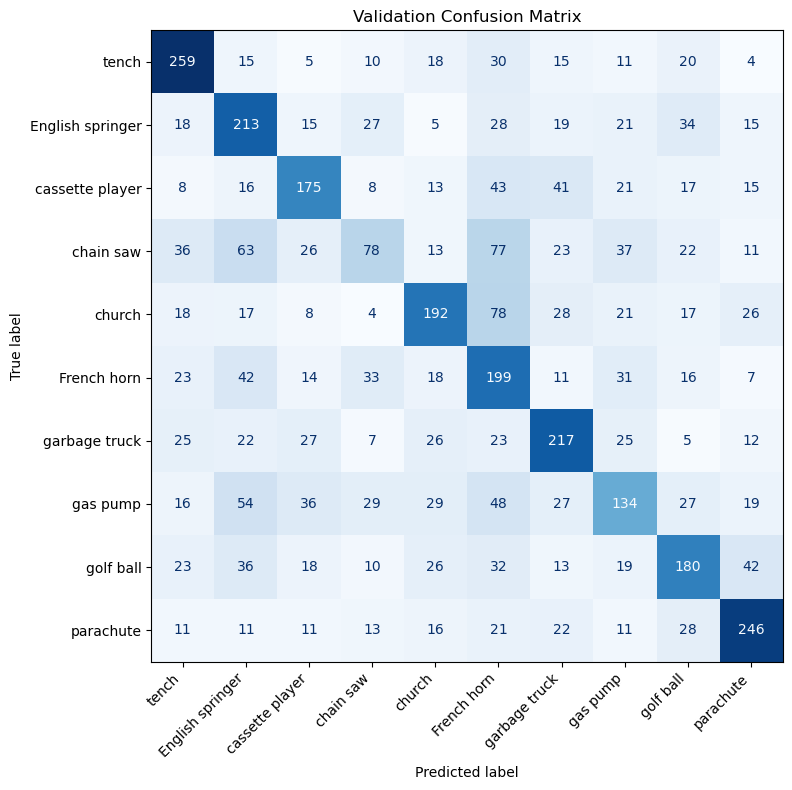

In [7]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix

# Load the best validation checkpoint saved during training.
# This evaluates the best model, not necessarily the model from the final epoch.
classification_model.load_state_dict(
    torch.load("best_multilayer_perceptron.pt", map_location=device)
)
classification_model.eval()

validation_predictions = []
validation_true_labels = []

with torch.no_grad():
    for validation_images, validation_labels in validation_dataloader:
        validation_images = validation_images.to(device, non_blocking=True)

        predicted_validation_logits = classification_model(validation_images)
        predicted_validation_classes = predicted_validation_logits.argmax(dim=1)

        # Move predictions and labels back to the CPU so scikit-learn can use them.
        validation_predictions.extend(predicted_validation_classes.cpu().tolist())
        validation_true_labels.extend(validation_labels.cpu().tolist())

# Convert the class mapping into a list ordered by numeric class index.
imagenette_synset_to_name = {
    "n01440764": "tench",
    "n02102040": "English springer",
    "n02979186": "cassette player",
    "n03000684": "chain saw",
    "n03028079": "church",
    "n03394916": "French horn",
    "n03417042": "garbage truck",
    "n03425413": "gas pump",
    "n03445777": "golf ball",
    "n03888257": "parachute",
}

index_to_class = {
    class_index: class_name
    for class_name, class_index in training_dataset.class_to_index.items()
}

class_names = [
    imagenette_synset_to_name.get(index_to_class[class_index], index_to_class[class_index])
    for class_index in range(number_of_classes)
]

class_indices = list(range(number_of_classes))

print("Validation Classification Report")
print(
    classification_report(
        validation_true_labels,
        validation_predictions,
        labels=class_indices,
        target_names=class_names,
        zero_division=0,
    )
)

validation_confusion_matrix = confusion_matrix(
    validation_true_labels,
    validation_predictions,
    labels=class_indices,
)

fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay(
    confusion_matrix=validation_confusion_matrix,
    display_labels=class_names,
).plot(
    ax=ax,
    cmap="Blues",
    colorbar=False,
    values_format="d",
)

ax.set_title("Validation Confusion Matrix")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## What to Tune First

When a model trains poorly, tune only a few things at a time. Good first experiments are:

- Learning rate: often the most important optimizer hyperparameter.
- Batch size: affects memory use, gradient noise, and speed.
- Number of epochs: too few underfits, too many may overfit.
- Dropout probability: larger values regularize more strongly.
- Weight decay: discourages large weights and can reduce overfitting.
- Data augmentation strength: too little may overfit, too much may make training too hard.

A useful habit is to watch both training loss and validation loss. If training loss improves but validation loss gets worse, the model is probably overfitting. If both losses stay high, the model may be underfitting, learning too slowly, or receiving incorrectly prepared data.


## Deep CNNs: AlexNet, ZFNet, and VGGNet

The MLP from earlier in this notebook treats each image as a flat vector of 150,528 numbers. Flattening throws away two properties that matter for images:

- **Spatial locality**: nearby pixels are related. An edge detector that works in one corner of an image works everywhere.
- **Translation equivariance**: the identity of an object should not change when it shifts by a few pixels.

A convolutional layer applies the same small filter at every spatial position in the feature map. A single 3×3 filter has 9 learned weights regardless of image size. The same filter detects a horizontal edge wherever it appears. This **weight sharing** keeps parameter counts manageable and gives the network built-in spatial awareness.

The three architectures below were each ImageNet champions in their year. Together they show how the field moved from aggressive downsampling (AlexNet), to visualization-driven refinement (ZFNet), to principled depth scaling (VGGNet).

### AlexNet (Krizhevsky, Sutskever, Hinton — 2012)

AlexNet won ILSVRC 2012 with a top-5 error rate of 15.3%, eleven points below the second-place entry. This margin was large enough to convince the research community that deep CNNs trained on GPUs were fundamentally different from prior approaches.

| Layer | Operation | Output shape |
|-------|-----------|-------------|
| Input | — | 3 × 224 × 224 |
| Conv1 | 64 filters, 11×11, stride 4 | 64 × 55 × 55 |
| MaxPool | 3×3, stride 2 | 64 × 27 × 27 |
| Conv2 | 192 filters, 5×5, pad 2 | 192 × 27 × 27 |
| MaxPool | 3×3, stride 2 | 192 × 13 × 13 |
| Conv3 | 384 filters, 3×3, pad 1 | 384 × 13 × 13 |
| Conv4 | 256 filters, 3×3, pad 1 | 256 × 13 × 13 |
| Conv5 | 256 filters, 3×3, pad 1 | 256 × 13 × 13 |
| MaxPool | 3×3, stride 2 | 256 × 6 × 6 |
| Dropout → FC | 9216 → 4096 | 4096 |
| Dropout → FC | 4096 → 4096 | 4096 |
| FC | 4096 → classes | classes |

The 11×11 first kernel with stride 4 aggressively compresses spatial size early — a practical necessity for 2012 GPU memory. The original used Local Response Normalization (LRN); we omit it because modern initialization and optimizers make it unnecessary. Dropout(0.5) in the classifier head was a novel regularization technique at the time.

In [8]:
class AlexNetClassifier(nn.Module):
    def __init__(self, number_of_classes: int, dropout_probability: float = 0.5):
        super().__init__()
        self.features = nn.Sequential(
            # Stem: aggressive downsampling to fit 2012 GPU memory budgets.
            nn.Conv2d(3, 64, kernel_size=11, stride=4, padding=2),   # 224 → 55
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),                   # 55 → 27

            nn.Conv2d(64, 192, kernel_size=5, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),                   # 27 → 13

            nn.Conv2d(192, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),                   # 13 → 6
        )
        self.pool = nn.AdaptiveAvgPool2d((6, 6))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(p=dropout_probability),
            nn.Linear(256 * 6 * 6, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout_probability),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Linear(4096, number_of_classes),
        )
        self._initialize_weights()

    def _initialize_weights(self):
        for module in self.modules():
            if isinstance(module, nn.Conv2d):
                nn.init.kaiming_normal_(module.weight, nonlinearity="relu")
                if module.bias is not None:
                    nn.init.zeros_(module.bias)
            elif isinstance(module, nn.Linear):
                nn.init.kaiming_normal_(module.weight, nonlinearity="relu")
                nn.init.zeros_(module.bias)

    def forward(self, input_images):
        features = self.features(input_images)
        pooled = self.pool(features)
        return self.classifier(pooled)


alexnet_model = AlexNetClassifier(number_of_classes=number_of_classes).to(device)
print(alexnet_model)

AlexNetClassifier(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (pool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Dropout(p=0.5, inplace=False)
    (2): Linear(

### ZFNet (Zeiler and Fergus — 2013)

ZFNet won ILSVRC 2013. Its primary contribution was not a dramatically different architecture — it was a method for *understanding* what convolutional layers learn. Zeiler and Fergus built the **deconvnet**: a technique that maps feature activations back to pixel space to visualize which input patterns cause each filter to fire.

Applying deconvnet to AlexNet, they found that the first layer produced aliased, low-quality features because the 11×11 kernel with stride 4 was too coarse. They made targeted adjustments based on what they observed:

| Change | AlexNet | ZFNet | Motivation |
|--------|---------|-------|------------|
| Conv1 kernel | 11×11 | 7×7 | Reduces stride aliasing |
| Conv1 stride | 4 | 2 | Preserves more spatial detail early |
| Conv2 stride | 1 | 2 | Compensates for smaller first stride |
| Conv3–5 filters | 384, 256, 256 | 384, 384, 256 | More capacity in deeper layers |

The classifier head is identical to AlexNet. With these changes, the first-layer filters learned clean, orientation-specific edge detectors instead of the blurry mixed-frequency patterns AlexNet produced.

In [9]:
class ZFNetClassifier(nn.Module):
    def __init__(self, number_of_classes: int, dropout_probability: float = 0.5):
        super().__init__()
        self.features = nn.Sequential(
            # Smaller stride preserves more spatial information in early layers.
            nn.Conv2d(3, 96, kernel_size=7, stride=2),                # 224 → 109
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),         # 109 → 55

            # stride=2 on conv2 compensates for the less aggressive conv1 stem.
            nn.Conv2d(96, 256, kernel_size=5, stride=2),              # 55 → 26
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),         # 26 → 13

            nn.Conv2d(256, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(384, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),                    # 13 → 6
        )
        self.pool = nn.AdaptiveAvgPool2d((6, 6))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(p=dropout_probability),
            nn.Linear(256 * 6 * 6, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout_probability),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Linear(4096, number_of_classes),
        )
        self._initialize_weights()

    def _initialize_weights(self):
        for module in self.modules():
            if isinstance(module, nn.Conv2d):
                nn.init.kaiming_normal_(module.weight, nonlinearity="relu")
                if module.bias is not None:
                    nn.init.zeros_(module.bias)
            elif isinstance(module, nn.Linear):
                nn.init.kaiming_normal_(module.weight, nonlinearity="relu")
                nn.init.zeros_(module.bias)

    def forward(self, input_images):
        features = self.features(input_images)
        pooled = self.pool(features)
        return self.classifier(pooled)


zfnet_model = ZFNetClassifier(number_of_classes=number_of_classes).to(device)
print(zfnet_model)

ZFNetClassifier(
  (features): Sequential(
    (0): Conv2d(3, 96, kernel_size=(7, 7), stride=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (3): Conv2d(96, 256, kernel_size=(5, 5), stride=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (6): Conv2d(256, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (pool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Dropout(p=0.5, inplace=False)
    (2): Linear(in_features=9216, out_features=4096,

### VGGNet (Simonyan and Zisserman — 2014)

VGGNet placed second at ILSVRC 2014 and became one of the most widely used feature extractors in the years that followed. Its central design principle is:

> **Replace large kernels with stacks of small (3×3) kernels.**

Two stacked 3×3 convolutions have the same receptive field as one 5×5, but use 2×9=18 weights instead of 25, and add an extra non-linearity. Three stacked 3×3 convolutions match one 7×7 (18 vs 49 weights) with two additional non-linearities. Smaller kernels with more depth consistently outperformed larger kernels with less depth.

| Block | Operations | Output size |
|-------|-----------|------------|
| Block 1 | 2 × Conv(64, 3×3) + MaxPool | 64 × 112 × 112 |
| Block 2 | 2 × Conv(128, 3×3) + MaxPool | 128 × 56 × 56 |
| Block 3 | 3 × Conv(256, 3×3) + MaxPool | 256 × 28 × 28 |
| Block 4 | 3 × Conv(512, 3×3) + MaxPool | 512 × 14 × 14 |
| Block 5 | 3 × Conv(512, 3×3) + MaxPool | 512 × 7 × 7 |
| Classifier | 25088 → 4096 → 4096 → classes | classes |

We add Batch Normalization after each convolution. The original VGGNet used no normalization. BN stabilizes training and generally improves accuracy at no cost in inference, so it is standard practice when implementing VGGNet today.

In [10]:
class VGGNetClassifier(nn.Module):
    def __init__(self, number_of_classes: int, dropout_probability: float = 0.5):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1: 224 → 112
            nn.Conv2d(3, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 2: 112 → 56
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 3: 56 → 28
            nn.Conv2d(128, 256, kernel_size=3, padding=1), nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1), nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1), nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 4: 28 → 14
            nn.Conv2d(256, 512, kernel_size=3, padding=1), nn.BatchNorm2d(512), nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1), nn.BatchNorm2d(512), nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1), nn.BatchNorm2d(512), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 5: 14 → 7
            nn.Conv2d(512, 512, kernel_size=3, padding=1), nn.BatchNorm2d(512), nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1), nn.BatchNorm2d(512), nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1), nn.BatchNorm2d(512), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        self.pool = nn.AdaptiveAvgPool2d((7, 7))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(p=dropout_probability),
            nn.Linear(512 * 7 * 7, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout_probability),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Linear(4096, number_of_classes),
        )
        self._initialize_weights()

    def _initialize_weights(self):
        for module in self.modules():
            if isinstance(module, nn.Conv2d):
                nn.init.kaiming_normal_(module.weight, nonlinearity="relu")
            elif isinstance(module, nn.BatchNorm2d):
                nn.init.ones_(module.weight)
                nn.init.zeros_(module.bias)
            elif isinstance(module, nn.Linear):
                nn.init.kaiming_normal_(module.weight, nonlinearity="relu")
                nn.init.zeros_(module.bias)

    def forward(self, input_images):
        features = self.features(input_images)
        pooled = self.pool(features)
        return self.classifier(pooled)


vggnet_model = VGGNetClassifier(number_of_classes=number_of_classes).to(device)
print(vggnet_model)

VGGNetClassifier(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU(inplace=True)
    (10): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU(inplace=True)
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Co

## Training CNN Architectures

The dataset, dataloaders, and device are already set up earlier in this notebook. The function below wraps the same training loop from the MLP section into a reusable form so each architecture can be trained with a single call.

The function follows every pattern established earlier: `zero_grad(set_to_none=True)`, gradient clipping, `non_blocking=True` transfers, cosine annealing, and best-checkpoint saving based on validation accuracy.

In [ ]:
def train_cnn(
    model,
    checkpoint_path,
    *,
    number_of_epochs: int = 30,
    learning_rate: float = 3e-4,
    weight_decay: float = 1e-4,
):
    model = model.to(device)

    loss_function = nn.CrossEntropyLoss(label_smoothing=0.05)

    optimizer = torch.optim.AdamW(
        params=model.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay,
    )

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer=optimizer,
        T_max=number_of_epochs,
    )

    history = {
        "training_loss": [],
        "validation_loss": [],
        "validation_accuracy": [],
    }
    best_validation_accuracy = 0.0

    for epoch_index in range(number_of_epochs):
        # --------------------------------------------------------
        # Training phase
        # --------------------------------------------------------
        model.train()
        total_training_loss = 0.0

        for training_images, training_labels in training_dataloader:
            training_images = training_images.to(device, non_blocking=True)
            training_labels = training_labels.to(device, non_blocking=True)

            predicted_logits = model(training_images)
            training_loss = loss_function(predicted_logits, training_labels)

            optimizer.zero_grad(set_to_none=True)
            training_loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            total_training_loss += training_loss.item() * training_images.size(0)

        scheduler.step()
        average_training_loss = total_training_loss / len(training_dataset)

        # --------------------------------------------------------
        # Validation phase
        # --------------------------------------------------------
        model.eval()
        total_validation_loss = 0.0
        number_of_correct = 0
        number_of_examples = 0

        with torch.no_grad():
            for validation_images, validation_labels in validation_dataloader:
                validation_images = validation_images.to(device, non_blocking=True)
                validation_labels = validation_labels.to(device, non_blocking=True)

                predicted_logits = model(validation_images)
                validation_loss = loss_function(predicted_logits, validation_labels)

                total_validation_loss += validation_loss.item() * validation_images.size(0)
                number_of_correct += (predicted_logits.argmax(dim=1) == validation_labels).sum().item()
                number_of_examples += validation_labels.size(0)

        average_validation_loss = total_validation_loss / len(validation_dataset)
        validation_accuracy = number_of_correct / number_of_examples

        history["training_loss"].append(average_training_loss)
        history["validation_loss"].append(average_validation_loss)
        history["validation_accuracy"].append(validation_accuracy)

        if validation_accuracy > best_validation_accuracy:
            best_validation_accuracy = validation_accuracy
            torch.save(
                {
                    "model_state": model.state_dict(),
                    "history": history,
                    "best_validation_accuracy": best_validation_accuracy,
                },
                checkpoint_path,
            )

        current_lr = scheduler.get_last_lr()[0]
        print(
            f"Epoch {epoch_index + 1:03d} | "
            f"Training Loss: {average_training_loss:.4f} | "
            f"Validation Loss: {average_validation_loss:.4f} | "
            f"Validation Accuracy: {validation_accuracy:.4f} | "
            f"LR: {current_lr:.6f}"
        )

    print(f"Best Validation Accuracy: {best_validation_accuracy:.4f}")
    return history, best_validation_accuracy

### AlexNet Experiment

AlexNet is the lightest of the three models. With 30 epochs on Imagenette it typically converges to around 70–75% validation accuracy. Its large first-layer stride means it loses fine spatial detail early, which limits performance on this 10-class dataset.

In [11]:
from pathlib import Path

alexnet_model = AlexNetClassifier(number_of_classes=number_of_classes).to(device)

checkpoint = torch.load("best_alexnet.pt", map_location=device, weights_only=False)
alexnet_model.load_state_dict(checkpoint["model_state"])
alexnet_history = checkpoint["history"]
alexnet_best_acc = checkpoint["best_validation_accuracy"]
print(f"Best validation accuracy: {alexnet_best_acc:.4f}")

Best validation accuracy: 0.8130


### ZFNet Experiment

ZFNet shares the same classifier head as AlexNet but produces richer early-layer features because its first convolution uses a 7×7 kernel with stride 2. Expect modestly higher accuracy than AlexNet on Imagenette, particularly on classes with fine texture detail.

In [12]:
zfnet_model = ZFNetClassifier(number_of_classes=number_of_classes).to(device)

checkpoint = torch.load("best_zfnet.pt", map_location=device, weights_only=False)
zfnet_model.load_state_dict(checkpoint["model_state"])
zfnet_history = checkpoint["history"]
zfnet_best_acc = checkpoint["best_validation_accuracy"]
print(f"Best validation accuracy: {zfnet_best_acc:.4f}")

Best validation accuracy: 0.8301


### VGGNet Experiment

VGGNet is the deepest of the three (13 conv layers vs AlexNet's 5). Its stack of 3×3 convolutions with Batch Normalization makes it slower per epoch but usually converges to higher accuracy. VGGNet is notably memory-intensive because the fully connected classifier holds most of its 138M parameters.

In [13]:
vggnet_model = VGGNetClassifier(number_of_classes=number_of_classes).to(device)

checkpoint = torch.load("best_vggnet.pt", map_location=device, weights_only=False)
vggnet_model.load_state_dict(checkpoint["model_state"])
vggnet_history = checkpoint["history"]
vggnet_best_acc = checkpoint["best_validation_accuracy"]
print(f"Best validation accuracy: {vggnet_best_acc:.4f}")

Best validation accuracy: 0.7689


### Comparing the Three Architectures

After training all three models, plot their validation accuracy curves together to compare how quickly each architecture learns and what ceiling it reaches.

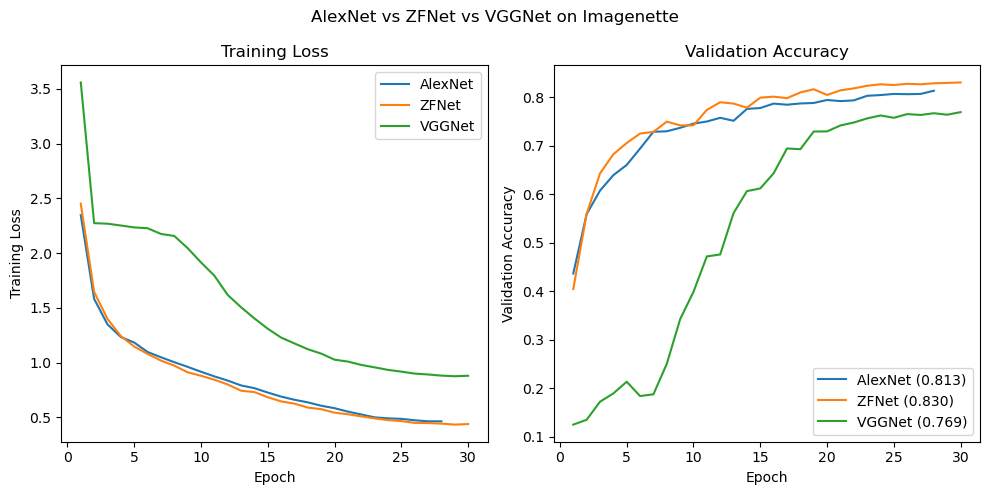

AlexNet  best val accuracy: 0.8130
ZFNet    best val accuracy: 0.8301
VGGNet   best val accuracy: 0.7689


In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
for name, history in [("AlexNet", alexnet_history), ("ZFNet", zfnet_history), ("VGGNet", vggnet_history)]:
    epochs = range(1, len(history["training_loss"]) + 1)
    plt.plot(epochs, history["training_loss"], label=name)
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss")
plt.legend()

plt.subplot(1, 2, 2)
for name, history, acc in [
    ("AlexNet", alexnet_history, alexnet_best_acc),
    ("ZFNet",   zfnet_history,   zfnet_best_acc),
    ("VGGNet",  vggnet_history,  vggnet_best_acc),
]:
    epochs = range(1, len(history["validation_accuracy"]) + 1)
    plt.plot(epochs, history["validation_accuracy"], label=f"{name} ({acc:.3f})")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy")
plt.legend()

plt.suptitle("AlexNet vs ZFNet vs VGGNet on Imagenette")
plt.tight_layout()
plt.show()

print(f"AlexNet  best val accuracy: {alexnet_best_acc:.4f}")
print(f"ZFNet    best val accuracy: {zfnet_best_acc:.4f}")
print(f"VGGNet   best val accuracy: {vggnet_best_acc:.4f}")

### Model Size Comparison

Higher accuracy is only meaningful relative to cost. The table below shows the trade-off between parameter count, memory, and accuracy for each architecture.

In [15]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

models_to_compare = {
    "AlexNet":  alexnet_model,
    "ZFNet":    zfnet_model,
    "VGGNet":   vggnet_model,
}

best_accs = {
    "AlexNet":  alexnet_best_acc,
    "ZFNet":    zfnet_best_acc,
    "VGGNet":   vggnet_best_acc,
}

print(f"{'Model':<10} {'Parameters':>15} {'Best Val Acc':>14}")
print("-" * 42)
for name, model in models_to_compare.items():
    params = count_parameters(model)
    acc = best_accs[name]
    print(f"{name:<10} {params:>15,} {acc:>14.4f}")

Model           Parameters   Best Val Acc
------------------------------------------
AlexNet         57,044,810         0.8130
ZFNet           58,301,578         0.8301
VGGNet         134,309,962         0.7689


## Homebrew CNN on CIFAR-10

CIFAR-10 is a standard benchmark: 60,000 32×32 RGB images across 10 classes (airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck), split 50,000 train / 10,000 test.

At 32×32, the AlexNet and VGGNet architectures above make no sense — their aggressive downsampling would collapse spatial dimensions to nothing before the first MaxPool. A CNN for small images needs a shallower stem and gentler downsampling.

The architecture below is designed specifically for 32×32:

```
Input       3 × 32 × 32
Block 1     Conv(32, 3×3) → BN → ReLU → MaxPool(2)    →  32 × 16 × 16
Block 2     Conv(64, 3×3) → BN → ReLU → MaxPool(2)    →  64 ×  8 ×  8
Block 3     Conv(128, 3×3) → BN → ReLU → MaxPool(2)   → 128 ×  4 ×  4
GlobalPool  AdaptiveAvgPool(1×1)                       → 128 ×  1 ×  1
Classifier  Flatten → Dropout → Linear(128, 10)        →  10 logits
```

Global average pooling collapses the spatial dimensions without a large FC layer, which keeps the parameter count very low (~200K vs AlexNet's ~58M).

In [19]:
from torchvision.datasets import CIFAR10

# CIFAR-10 normalization constants (computed from the training set).
cifar10_mean = [0.4914, 0.4822, 0.4465]
cifar10_std  = [0.2470, 0.2435, 0.2616]

# RandomCrop with padding=4 is the canonical CIFAR-10 augmentation.
# It shifts the image by up to 4 pixels in each direction before cropping.
cifar10_train_transforms = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToImage(),
    transforms.ToDtype(dtype=torch.float32, scale=True),
    transforms.Normalize(mean=cifar10_mean, std=cifar10_std),
])

cifar10_val_transforms = transforms.Compose([
    transforms.ToImage(),
    transforms.ToDtype(dtype=torch.float32, scale=True),
    transforms.Normalize(mean=cifar10_mean, std=cifar10_std),
])

cifar10_train_dataset = CIFAR10(
    root="../../datasets",
    train=True,
    download=True,
    transform=cifar10_train_transforms,
)

cifar10_val_dataset = CIFAR10(
    root="../../datasets",
    train=False,
    download=True,
    transform=cifar10_val_transforms,
)

cifar10_train_loader = DataLoader(
    dataset=cifar10_train_dataset,
    batch_size=128,
    shuffle=True,
    num_workers=4,
    pin_memory=(device.type == "cuda"),
)

cifar10_val_loader = DataLoader(
    dataset=cifar10_val_dataset,
    batch_size=256,
    shuffle=False,
    num_workers=4,
    pin_memory=(device.type == "cuda"),
)

cifar10_classes = cifar10_train_dataset.classes
print(f"Classes: {cifar10_classes}")
print(f"Training examples: {len(cifar10_train_dataset)}")
print(f"Validation examples: {len(cifar10_val_dataset)}")

Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Training examples: 50000
Validation examples: 10000


In [20]:
class HomebrewCNN(nn.Module):
    def __init__(self, number_of_classes: int = 10, dropout_probability: float = 0.3):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1: 32 → 16
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 2: 16 → 8
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 3: 8 → 4
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        # Global average pooling: 128 × 4 × 4 → 128 × 1 × 1
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(p=dropout_probability),
            nn.Linear(128, number_of_classes),
        )
        self._initialize_weights()

    def _initialize_weights(self):
        for module in self.modules():
            if isinstance(module, nn.Conv2d):
                nn.init.kaiming_normal_(module.weight, nonlinearity="relu")
                if module.bias is not None:
                    nn.init.zeros_(module.bias)
            elif isinstance(module, nn.BatchNorm2d):
                nn.init.ones_(module.weight)
                nn.init.zeros_(module.bias)
            elif isinstance(module, nn.Linear):
                nn.init.kaiming_normal_(module.weight, nonlinearity="relu")
                nn.init.zeros_(module.bias)

    def forward(self, input_images):
        features = self.features(input_images)
        pooled = self.pool(features)
        return self.classifier(pooled)


homebrew_model = HomebrewCNN(number_of_classes=10).to(device)
print(homebrew_model)

total_params = sum(p.numel() for p in homebrew_model.parameters() if p.requires_grad)
print(f"\nTrainable parameters: {total_params:,}")

HomebrewCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (pool): AdaptiveAvgPool2d(output_size=(1, 1))
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1):

In [21]:
homebrew_model = HomebrewCNN(number_of_classes=10).to(device)

checkpoint = torch.load("best_homebrew_cnn.pt", map_location=device, weights_only=False)
homebrew_model.load_state_dict(checkpoint["model_state"])
cifar10_history = checkpoint["history"]
cifar10_best_accuracy = checkpoint["best_validation_accuracy"]
print(f"Best validation accuracy: {cifar10_best_accuracy:.4f}")

Best validation accuracy: 0.6421


Validation Classification Report
              precision    recall  f1-score   support

    airplane       0.65      0.68      0.67      1000
  automobile       0.76      0.76      0.76      1000
        bird       0.53      0.51      0.52      1000
         cat       0.46      0.38      0.41      1000
        deer       0.59      0.54      0.56      1000
         dog       0.53      0.63      0.57      1000
        frog       0.65      0.77      0.70      1000
       horse       0.73      0.65      0.69      1000
        ship       0.75      0.77      0.76      1000
       truck       0.75      0.74      0.74      1000

    accuracy                           0.64     10000
   macro avg       0.64      0.64      0.64     10000
weighted avg       0.64      0.64      0.64     10000



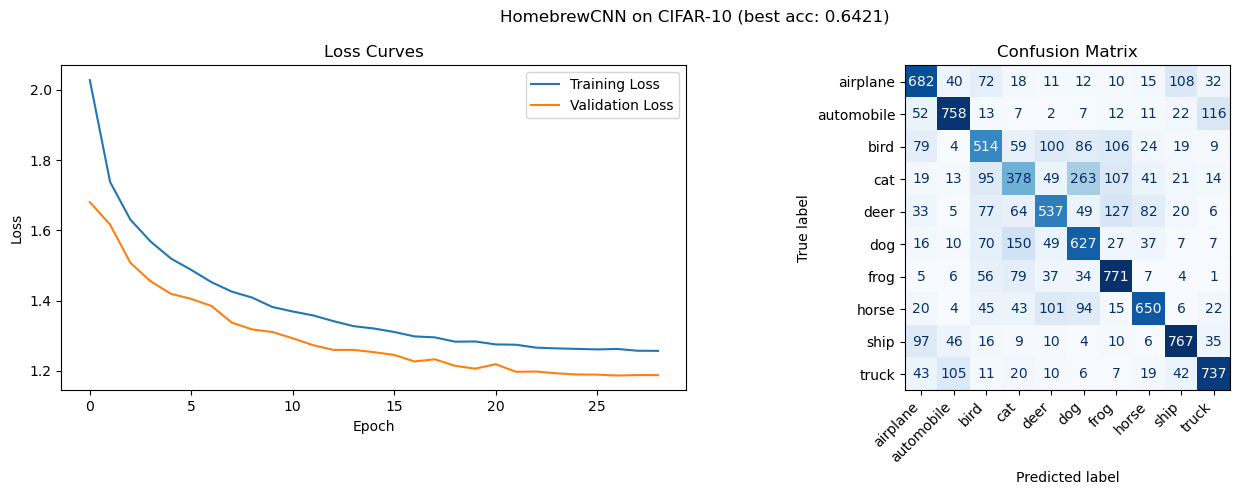

In [22]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix

homebrew_model.load_state_dict(
    torch.load("best_homebrew_cnn.pt", map_location=device, weights_only=False)["model_state"]
)
homebrew_model.eval()

all_predictions = []
all_true_labels = []

with torch.no_grad():
    for validation_images, validation_labels in cifar10_val_loader:
        validation_images = validation_images.to(device, non_blocking=True)
        predicted_logits = homebrew_model(validation_images)
        all_predictions.extend(predicted_logits.argmax(dim=1).cpu().tolist())
        all_true_labels.extend(validation_labels.cpu().tolist())

print("Validation Classification Report")
print(classification_report(all_true_labels, all_predictions, target_names=cifar10_classes))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(cifar10_history["training_loss"], label="Training Loss")
axes[0].plot(cifar10_history["validation_loss"], label="Validation Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss Curves")
axes[0].legend()

validation_confusion_matrix = confusion_matrix(all_true_labels, all_predictions)
ConfusionMatrixDisplay(
    confusion_matrix=validation_confusion_matrix,
    display_labels=cifar10_classes,
).plot(ax=axes[1], cmap="Blues", colorbar=False, values_format="d")
axes[1].set_title("Confusion Matrix")
plt.xticks(rotation=45, ha="right")

plt.suptitle(f"HomebrewCNN on CIFAR-10 (best acc: {cifar10_best_accuracy:.4f})")
plt.tight_layout()
plt.show()